# M51 JWST Exploration

## Research question

What are the actual JWST observations returned by MAST for M51?

## Goals

1. Identify the JWST observations associated with M51.
2. Examine the metadata returned by MAST.
3. Determine which JWST instruments and filters are represented.
4. Examine proposal IDs and target names.
5. Examine observation identifiers and dates.
6. Determine how MAST observations relate to the underlying data products.
7. Use these findings to design a better Cosmic AI JWST search tool.

## Method

Use `astroquery.mast.Observations` to query MAST.

The notebook is an exploratory scientific record. Production tools will be
updated only after the observations and metadata have been examined.

In [ ]:
# ===================================
# Import tools
# ===================================

from astroquery.mast import Observations
import astropy
import astroquery

print("Astroquery:", astroquery.__version__)
print("Astropy:", astropy.__version__)

In [ ]:
# ====================================
# MAST search
# ====================================

obs_all = Observations.query_object(
    "M51",
    radius="0.02 deg"
)

print("Total observations:", len(obs_all))

In [ ]:
# ====================================
# Column names
# ====================================

print(obs_all.colnames)

In [ ]:
# ====================================
# Information
# ====================================

obs_all.info()

In [ ]:
# ========================================
# First 5 entries
# ========================================

obs_all[:5]

In [ ]:
# ==================================
# Isolate JWST
# ==================================

jwst = obs_all[
    obs_all["obs_collection"] == "JWST"
]

print("JWST observations:", len(jwst))

In [ ]:
jwst[[
    "obs_id",
    "instrument_name",
    "filters",
    "target_name",
    "proposal_id",
    "calib_level"
]][:20]

In [ ]:
sorted(set(jwst["calib_level"]))

In [ ]:
from collections import Counter

Counter(jwst["calib_level"])

In [ ]:
# =============================
# Proposal counts
# =============================

proposal_counts = Counter(
    int(value)
    for value in jwst["proposal_id"]
)

print("Distinct JWST proposals:", len(proposal_counts))
print(proposal_counts)

In [ ]:
proposal_3435[[
    "obs_id",
    "instrument_name",
    "filters",
    "target_name"
]][:30]

In [ ]:
# ============================
# Instrument breakdown
# ============================

Counter(
    str(value)
    for value in proposal_3435["instrument_name"]
)

In [ ]:
# =============================
# Target breakdown
# =============================

Counter(
    str(value)
    for value in proposal_3435["target_name"]
)

In [ ]:
# =============================
# Filter breakdown
# =============================

Counter(
    str(value)
    for value in proposal_3435["filters"]
)

In [ ]:
# ==================================
# Common observation IDs
# ==================================

import re

def common_obs_id(obs_id):
    match = re.match(r"^(jw\d+-[oc]\d+_t\d+)", str(obs_id))
    return match.group(1) if match else None

proposal_3435_common_ids = [
    common_obs_id(value)
    for value in proposal_3435["obs_id"]
]

print(
    "Unique common observation IDs:",
    len(set(proposal_3435_common_ids))
)

In [ ]:
nirspec = proposal_3435[
    proposal_3435["instrument_name"] == "NIRSPEC/IFU"
]

print("NIRSpec records:", len(nirspec))

In [ ]:
print(nirspec[0])

In [ ]:
nirspec[[
    "obs_id",
    "obsid",
    "target_name",
    "instrument_name",
    "filters",
    "proposal_id",
    "calib_level"
]][:10]

In [ ]:
products = Observations.get_product_list("213040996")

print("Number of products:", len(products))

In [ ]:
products[[
    "obsID",
    "productFilename",
    "productType",
    "calib_level",
    "filters"
]]

In [ ]:
Counter(products["productType"])

In [ ]:
Counter(products["calib_level"])

In [ ]:
science_products = products[
    products["productType"] == "SCIENCE"
]

print("Science products:", len(science_products))

In [ ]:
science_products[
    [
        "obsID",
        "productFilename",
        "calib_level",
        "filters"
    ]
][:30]

In [ ]:
# ==================================
# Select the two preview files
# ==================================

preview_names = [
    "jw03435-o006_t010_nirspec_g140m-f100lp_s3d.jpg",
    "jw03435-o006_t010_nirspec_g140m-f100lp_x1d.png",
]

preview_products = products[
    [name in preview_names for name in products["productFilename"]]
]

preview_products[
    ["obsID", "productFilename", "productType", "calib_level", "filters"]
]

In [ ]:
# ==================================
# Download the two preview files
# ==================================

from pathlib import Path

preview_dir = Path("../data/m51_jwst_previews")
preview_dir.mkdir(parents=True, exist_ok=True)

manifest = Observations.download_products(
    preview_products,
    download_dir=str(preview_dir)
)

manifest

In [ ]:
for path in preview_dir.rglob("*"):
    if path.is_file():
        print(path)

In [ ]:
from IPython.display import Image, display

In [ ]:
preview_files = list(preview_dir.rglob("*.jpg")) + list(preview_dir.rglob("*.png"))

for path in preview_files:
    print(path)

In [ ]:
for path in preview_files:
    print(path.name)
    display(Image(filename=str(path)))

In [ ]:
# ===============================
# Select the two FITS files
# ===============================

science_filenames = [
    "jw03435-o006_t010_nirspec_g140m-f100lp_s3d.fits",
    "jw03435-o006_t010_nirspec_g140m-f100lp_x1d.fits",
]

science_products = products[
    [name in science_filenames for name in products["productFilename"]]
]

science_products[
    ["obsID", "productFilename", "productType", "calib_level", "filters"]
]

In [ ]:
# =============================
# Download the two FITS files
# =============================

from pathlib import Path

science_dir = Path("../data/m51_jwst_level3")
science_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
manifest = Observations.download_products(
    science_products,
    download_dir=str(science_dir),
    flat=True
)

manifest

In [ ]:
# ==================================
# Verify the files
# ==================================

for path in science_dir.iterdir():
    print(path.name, path.stat().st_size / 1024**2, "MB")

## 6. Scientific Investigation of the NIRSpec/IFU Level-3 Data

We now begin detailed investigation of the selected JWST NIRSpec/IFU
Level-3 data cube.

The objective is to determine the cube's structure, wavelength coverage,
spatial sampling, and available metadata before attempting scientific
interpretation.

In [1]:
from pathlib import Path
from astropy.io import fits

s3d_path = Path(
    "../data/m51_jwst_level3/"
    "jw03435-o006_t010_nirspec_g140m-f100lp_s3d.fits"
)

hdul = fits.open(s3d_path)

hdul.info()

Filename: ../data/m51_jwst_level3/jw03435-o006_t010_nirspec_g140m-f100lp_s3d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     278   ()      
  1  SCI           1 ImageHDU        92   (125, 97, 1447)   float32   
  2  ERR           1 ImageHDU        12   (125, 97, 1447)   float32   
  3  DQ            1 ImageHDU        12   (125, 97, 1447)   int32 (rescales to uint32)   
  4  WMAP          1 ImageHDU        10   (125, 97, 1447)   float32   
  5  WCS-TABLE     1 BinTableHDU     13   1R x 1C   [1447E]   
  6  HDRTAB        1 BinTableHDU    520   16R x 255C   [23A, 5A, 3A, 39A, 7A, 13A, 3A, 5A, 5A, 7A, 13A, 4A, L, D, D, 32A, 49A, 34A, 22A, 2A, 8A, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 1A, L, 24A, 20A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 13A, 1A, 5A, D, D, D, D, D, D, D, D, 7A, 7A, 4A, 6A, 5A, K, 4A, 3A, D, D, D, D, D, D, D, K, 5A, 7A, D, D, D, D, D, D, D, D, D, 12A, K, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, D

In [2]:
print(hdul[0].header)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  DATE    = '2026-07-06T09:37:33.025' / UTC date file created                     ORIGIN  = 'STSCI   '           / Organization responsible for creating file     TIMESYS = 'UTC     '           / principal time system for time-related keywordsTIMEUNIT= 's       '           / Default unit applicable to all time values     FILENAME= 'jw03435-o006_t010_nirspec_g140m-f100lp_s3d.fits' / Name of the file  SDP_VER = '2026_1b '           / Data Processing (DP) Software Version          PRD_VER = 'PRDOPSSOC-073'      / S&OC Project Reference Database (PRD) Version  OSS_VER = '9.2     '           / Observatory Scheduling Software (OSS) Version  GSC_VER = 'GSC32   '           / Guide S

In [3]:
for hdu in hdul:
    print(
        hdu.name,
        "shape =", getattr(hdu.data, "shape", None),
        "dtype =", getattr(hdu.data, "dtype", None),
    )

PRIMARY shape = None dtype = None
SCI shape = (1447, 97, 125) dtype = >f4
ERR shape = (1447, 97, 125) dtype = >f4
DQ shape = (1447, 97, 125) dtype = uint32
WMAP shape = (1447, 97, 125) dtype = >f4
WCS-TABLE shape = (1,) dtype = (numpy.record, [('wavelength', '>f4', (1447, 1))])
HDRTAB shape = (16,) dtype = (numpy.record, [('DATE', 'S23'), ('ORIGIN', 'S5'), ('TIMESYS', 'S3'), ('FILENAME', 'S39'), ('SDP_VER', 'S7'), ('PRD_VER', 'S13'), ('OSS_VER', 'S3'), ('GSC_VER', 'S5'), ('CAL_VER', 'S5'), ('CAL_VCS', 'S7'), ('DATAMODL', 'S13'), ('TELESCOP', 'S4'), ('HGA_MOVE', 'i1'), ('PWFSEET', '>f8'), ('NWFSEST', '>f8'), ('ASNPOOL', 'S32'), ('ASNTABLE', 'S49'), ('TITLE', 'S34'), ('PI_NAME', 'S22'), ('CATEGORY', 'S2'), ('SCICAT', 'S8'), ('DATE-OBS', 'S10'), ('TIME-OBS', 'S12'), ('DATE-BEG', 'S23'), ('DATE-END', 'S23'), ('OBS_ID', 'S26'), ('VISIT_ID', 'S11'), ('PROGRAM', 'S5'), ('OBSERVTN', 'S3'), ('VISIT', 'S3'), ('VISITGRP', 'S2'), ('SEQ_ID', 'S1'), ('ACT_ID', 'S2'), ('EXPOSURE', 'S1'), ('BKGDTARG',

In [4]:
from astropy.wcs import WCS

sci_hdu = hdul["SCI"]

wcs = WCS(sci_hdu.header)

print(wcs)

WCS Keywords

Number of WCS axes: 3
CTYPE : 'RA---TAN' 'DEC--TAN' 'WAVE'
CUNIT : 'deg' 'deg' 'm'
CRVAL : -157.5179149855 47.195903588 9.703180286160204e-07
CRPIX : 63.0 49.0 1.0
PC1_1 PC1_2 PC1_3  : -1.0 0.0 0.0
PC2_1 PC2_2 PC2_3  : 0.0 1.0 0.0
PC3_1 PC3_2 PC3_3  : 0.0 0.0 1.0
CDELT : 2.77777781916989e-05 2.77777781916989e-05 6.36000011581927e-10
NAXIS : 125  97  1447


Set DATE-AVG to '2024-04-06T18:00:25.292' from MJD-AVG.
Set DATE-END to '2024-04-06T18:41:47.344' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -0.239387 from OBSGEO-[XYZ].
Set OBSGEO-H to 1271318235.914 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [5]:
print(wcs.world_axis_names)
print(wcs.pixel_n_dim)
print(wcs.world_n_dim)

['', '', '']
3
3


In [6]:
from astropy.wcs.utils import pixel_to_skycoord
from astropy.coordinates import SkyCoord

# Reference pixel from the WCS
coord = pixel_to_skycoord(
    62, 48,
    wcs.celestial,
    origin=0
)

print(coord)
print("RA:", coord.ra.deg)
print("Dec:", coord.dec.deg)

<SkyCoord (ICRS): (ra, dec) in deg
    (202.48208501, 47.19590359)>
RA: 202.4820850145
Dec: 47.195903588


In [7]:
import numpy as np

spec_axis = np.arange(1447)

wavelength = wcs.spectral.pixel_to_world_values(spec_axis)

print("First wavelength:", wavelength[0], "m")
print("Last wavelength:", wavelength[-1], "m")
print("Number of wavelengths:", len(wavelength))

First wavelength: 9.703180286160204e-07 m
Last wavelength: 1.8899740453634867e-06 m
Number of wavelengths: 1447


In [8]:
wavelength_um = wavelength * 1e6

print("First wavelength:", wavelength_um[0], "µm")
print("Last wavelength:", wavelength_um[-1], "µm")

First wavelength: 0.9703180286160203 µm
Last wavelength: 1.8899740453634868 µm


In [9]:
sci = hdul["SCI"].data

print(sci.shape)
print(np.nanmin(sci))
print(np.nanmax(sci))
print(np.nanmedian(sci))

(1447, 97, 125)
-2256.8647
23054.594
5.750462


In [10]:
print("SCI BUNIT:", hdul["SCI"].header.get("BUNIT"))
print("SCI EXTNAME:", hdul["SCI"].header.get("EXTNAME"))
print("Data type:", hdul["SCI"].data.dtype)
print("Shape:", hdul["SCI"].data.shape)

SCI BUNIT: MJy/sr
SCI EXTNAME: SCI
Data type: >f4
Shape: (1447, 97, 125)


In [11]:
sci = hdul["SCI"].data

print("NaN count:", np.isnan(sci).sum())
print("Total pixels:", sci.size)
print("Finite pixels:", np.isfinite(sci).sum())

NaN count: 10739718
Total pixels: 17544875
Finite pixels: 6805157


In [12]:
finite = sci[np.isfinite(sci)]

print("Minimum:", np.min(finite))
print("Maximum:", np.max(finite))
print("Median:", np.median(finite))
print("Mean:", np.mean(finite))
print("Standard deviation:", np.std(finite))

Minimum: -2256.8647
Maximum: 23054.594
Median: 5.750462
Mean: 6.3540254
Standard deviation: 12.260395


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Choose the wavelength nearest the middle of the spectral range
target_wavelength_um = 1.43

index = np.argmin(np.abs(wavelength_um - target_wavelength_um))

slice_data = sci[index]

print("Spectral index:", index)
print("Actual wavelength:", wavelength_um[index], "µm")
print("Slice shape:", slice_data.shape)
print("Finite pixels:", np.isfinite(slice_data).sum())

Spectral index: 723
Actual wavelength: 1.4301460369897536 µm
Slice shape: (97, 125)
Finite pixels: 4697


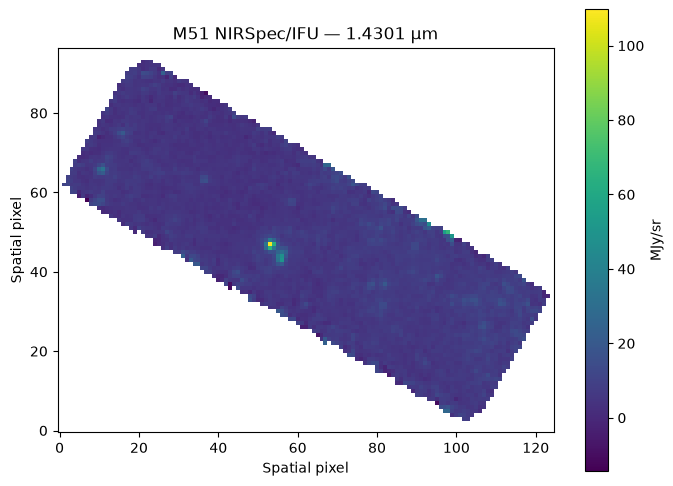

In [14]:
plt.figure(figsize=(8, 6))

plt.imshow(
    slice_data,
    origin="lower",
    aspect="equal"
)

plt.colorbar(label="MJy/sr")

plt.title(
    f"M51 NIRSpec/IFU — {wavelength_um[index]:.4f} µm"
)

plt.xlabel("Spatial pixel")
plt.ylabel("Spatial pixel")

plt.show()

In [15]:
max_index = np.nanargmax(sci)
max_position = np.unravel_index(max_index, sci.shape)

print("Maximum value:", sci[max_position])
print("Cube position (spectral, y, x):", max_position)

spectral_index = max_position[0]
print("Wavelength:", wavelength_um[spectral_index], "µm")

Maximum value: 23054.594
Cube position (spectral, y, x): (np.int64(1104), np.int64(62), np.int64(74))
Wavelength: 1.6724620414024678 µm


In [16]:
z, y, x = max_position
spectrum = sci[:, y, x]

print("Spatial position:", x, y)
print("Spectrum length:", len(spectrum))
print("Finite spectral points:", np.isfinite(spectrum).sum())

Spatial position: 74 62
Spectrum length: 1447
Finite spectral points: 1447


In [17]:
# ==============================
# Plot the spectrum
# ==============================

z, y, x = max_position
spectrum = sci[:, y, x]

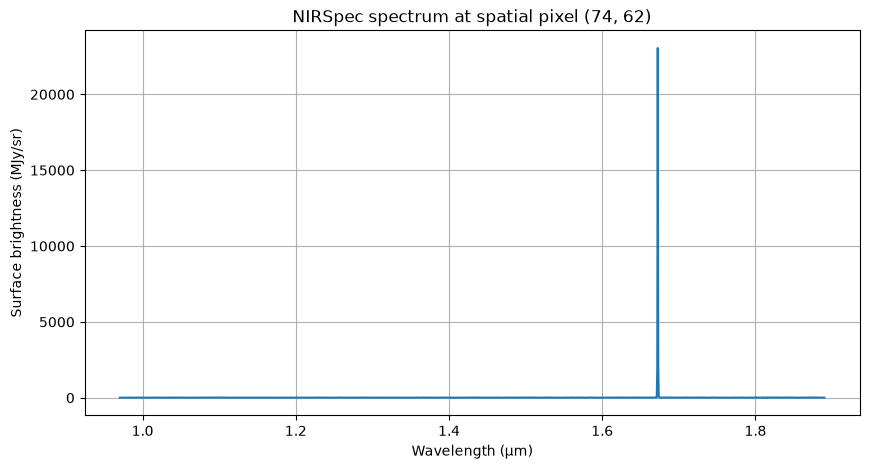

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(wavelength_um, spectrum)

plt.xlabel("Wavelength (µm)")
plt.ylabel("Surface brightness (MJy/sr)")
plt.title(f"NIRSpec spectrum at spatial pixel ({x}, {y})")

plt.grid(True)
plt.show()

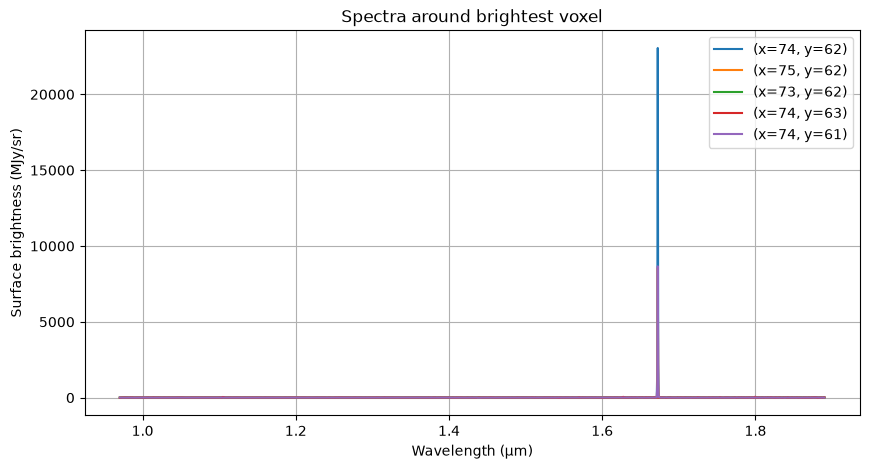

In [19]:
# ============================
# Comparison plot
# ============================

plt.figure(figsize=(10, 5))

for dy, dx in [(0, 0), (0, 1), (0, -1), (1, 0), (-1, 0)]:
    local_spectrum = sci[:, y + dy, x + dx]

    plt.plot(
        wavelength_um,
        local_spectrum,
        label=f"(x={x+dx}, y={y+dy})"
    )

plt.xlabel("Wavelength (µm)")
plt.ylabel("Surface brightness (MJy/sr)")
plt.title("Spectra around brightest voxel")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
peak_index = spectral_index

for dy, dx in [(0, 0), (0, 1), (0, -1), (1, 0), (-1, 0)]:
    value = sci[peak_index, y + dy, x + dx]

    print(
        f"x={x+dx:3d}, y={y+dy:3d} "
        f"value={value:12.3f} MJy/sr"
    )

x= 74, y= 62 value=   23054.594 MJy/sr
x= 75, y= 62 value=    8544.437 MJy/sr
x= 73, y= 62 value=     494.777 MJy/sr
x= 74, y= 63 value=      -0.599 MJy/sr
x= 74, y= 61 value=    8657.464 MJy/sr


In [21]:
start = peak_index - 10
end = peak_index + 11

for i in range(start, end):
    print(
        f"{i:4d}  "
        f"{wavelength_um[i]:.9f} µm  "
        f"{spectrum[i]:12.3f} MJy/sr"
    )

1094  1.666102041 µm        10.598 MJy/sr
1095  1.666738041 µm         6.253 MJy/sr
1096  1.667374041 µm         2.872 MJy/sr
1097  1.668010041 µm        16.799 MJy/sr
1098  1.668646041 µm        12.520 MJy/sr
1099  1.669282041 µm        14.388 MJy/sr
1100  1.669918041 µm         7.145 MJy/sr
1101  1.670554041 µm        15.975 MJy/sr
1102  1.671190041 µm        35.591 MJy/sr
1103  1.671826041 µm      1962.812 MJy/sr
1104  1.672462041 µm     23054.594 MJy/sr
1105  1.673098041 µm      2232.636 MJy/sr
1106  1.673734041 µm       116.984 MJy/sr
1107  1.674370041 µm        20.399 MJy/sr
1108  1.675006041 µm         5.913 MJy/sr
1109  1.675642041 µm        14.283 MJy/sr
1110  1.676278041 µm         7.516 MJy/sr
1111  1.676914041 µm         2.660 MJy/sr
1112  1.677550041 µm        11.692 MJy/sr
1113  1.678186042 µm         9.413 MJy/sr
1114  1.678822042 µm        11.598 MJy/sr


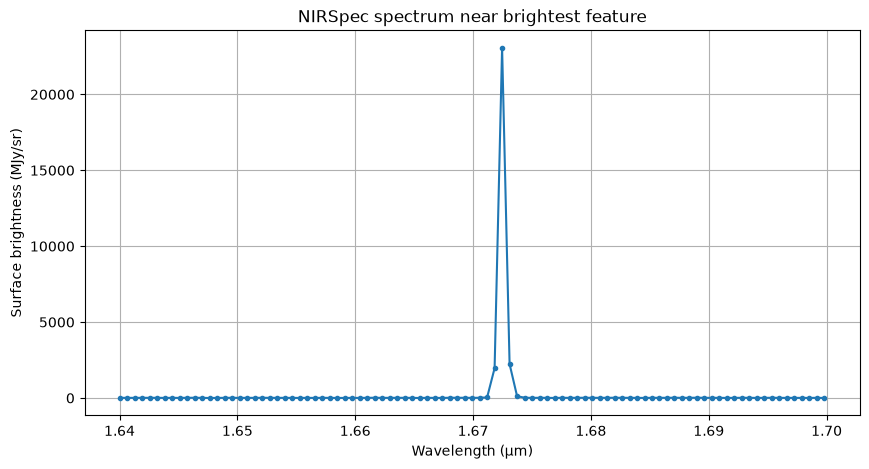

In [22]:
window = (
    (wavelength_um >= 1.64) &
    (wavelength_um <= 1.70)
)

plt.figure(figsize=(10, 5))

plt.plot(
    wavelength_um[window],
    spectrum[window],
    marker="o",
    markersize=3
)

plt.xlabel("Wavelength (µm)")
plt.ylabel("Surface brightness (MJy/sr)")
plt.title("NIRSpec spectrum near brightest feature")
plt.grid(True)

plt.show()

## 7. Validation of the NIRSpec Spectral Feature

A strong spectral feature was identified in the S3D cube near
1.672462 µm. The next step is to determine whether this feature
is independently present in the associated Level-3 X1D product.

In [23]:
from pathlib import Path
from astropy.io import fits

x1d_path = Path(
    "../data/m51_jwst_level3/"
    "jw03435-o006_t010_nirspec_g140m-f100lp_x1d.fits"
)

x1d_hdul = fits.open(x1d_path)

x1d_hdul.info()

Filename: ../data/m51_jwst_level3/jw03435-o006_t010_nirspec_g140m-f100lp_x1d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     270   ()      
  1  EXTRACT1D     1 BinTableHDU     71   1447R x 18C   [D, D, D, D, D, D, D, D, D, D, D, J, D, D, D, D, D, D]   
  2  ASDF          1 BinTableHDU     11   1R x 1C   [119296B]   


In [24]:
x1d_table = x1d_hdul["EXTRACT1D"].data

print(x1d_table.names)

['WAVELENGTH', 'FLUX', 'FLUX_ERROR', 'FLUX_VAR_POISSON', 'FLUX_VAR_RNOISE', 'FLUX_VAR_FLAT', 'SURF_BRIGHT', 'SB_ERROR', 'SB_VAR_POISSON', 'SB_VAR_RNOISE', 'SB_VAR_FLAT', 'DQ', 'BACKGROUND', 'BKGD_ERROR', 'BKGD_VAR_POISSON', 'BKGD_VAR_RNOISE', 'BKGD_VAR_FLAT', 'NPIXELS']


In [25]:
for name in x1d_table.names:
    print(name, x1d_table[name].dtype)

WAVELENGTH >f8
FLUX >f8
FLUX_ERROR >f8
FLUX_VAR_POISSON >f8
FLUX_VAR_RNOISE >f8
FLUX_VAR_FLAT >f8
SURF_BRIGHT >f8
SB_ERROR >f8
SB_VAR_POISSON >f8
SB_VAR_RNOISE >f8
SB_VAR_FLAT >f8
DQ uint32
BACKGROUND >f8
BKGD_ERROR >f8
BKGD_VAR_POISSON >f8
BKGD_VAR_RNOISE >f8
BKGD_VAR_FLAT >f8
NPIXELS >f8


In [26]:
print(x1d_table[0])

(np.float64(0.9703180286160205), np.float64(0.0044328874717509325), np.float64(2.6777685329538803e-05), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(4.221159387831007), np.float64(0.025498702264264983), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.uint32(0), np.float64(4.046816616708245), np.float64(0.024689048091614915), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(4468.0))


In [27]:
print("WAVELENGTH unit:",
      x1d_hdul["EXTRACT1D"].header.get("TUNIT1"))

print("FLUX unit:",
      x1d_hdul["EXTRACT1D"].header.get("TUNIT2"))

print("SURF_BRIGHT unit:",
      x1d_hdul["EXTRACT1D"].header.get("TUNIT7"))

WAVELENGTH unit: um
FLUX unit: Jy
SURF_BRIGHT unit: MJy/sr


In [28]:
x1d_wavelength = x1d_table["WAVELENGTH"]

print("First:", x1d_wavelength[0], "µm")
print("Last:", x1d_wavelength[-1], "µm")
print("Number:", len(x1d_wavelength))

First: 0.9703180286160205 µm
Last: 1.8899740453634877 µm
Number: 1447


In [29]:
target = 1.6724620414024678

x1d_index = np.argmin(
    np.abs(x1d_wavelength - target)
)

print("S3D target wavelength:", target, "µm")
print("X1D nearest index:", x1d_index)
print("X1D wavelength:", x1d_wavelength[x1d_index], "µm")

print()
print("X1D SURF_BRIGHT:",
      x1d_table["SURF_BRIGHT"][x1d_index],
      "MJy/sr")

print("X1D SB_ERROR:",
      x1d_table["SB_ERROR"][x1d_index],
      "MJy/sr")

print("X1D DQ:",
      x1d_table["DQ"][x1d_index])

print("X1D NPIXELS:",
      x1d_table["NPIXELS"][x1d_index])

S3D target wavelength: 1.6724620414024678 µm
X1D nearest index: 1104
X1D wavelength: 1.6724620414024685 µm

X1D SURF_BRIGHT: 16.119589021662744 MJy/sr
X1D SB_ERROR: 0.19988151663707948 MJy/sr
X1D DQ: 0
X1D NPIXELS: 4698.0


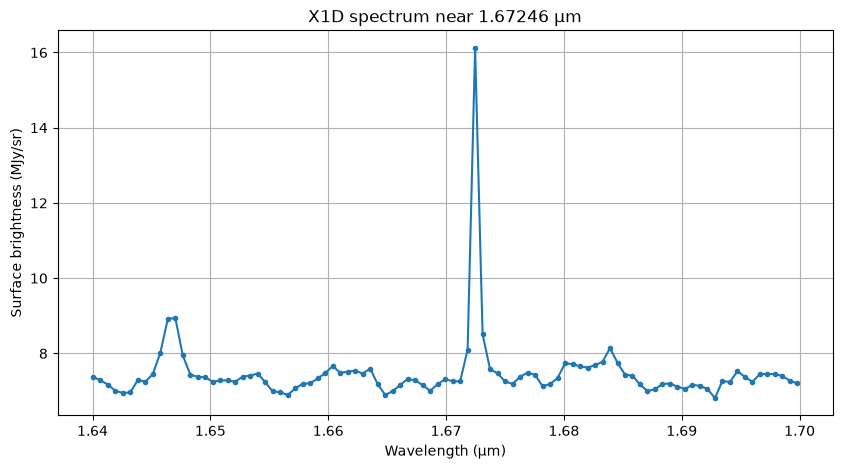

In [30]:
x1d_window = (
    (x1d_wavelength >= 1.64) &
    (x1d_wavelength <= 1.70)
)

plt.figure(figsize=(10, 5))

plt.plot(
    x1d_wavelength[x1d_window],
    x1d_table["SURF_BRIGHT"][x1d_window],
    marker="o",
    markersize=3
)

plt.xlabel("Wavelength (µm)")
plt.ylabel("Surface brightness (MJy/sr)")
plt.title("X1D spectrum near 1.67246 µm")
plt.grid(True)

plt.show()

In [31]:
start = 1094
end = 1115

for i in range(start, end):
    print(
        f"{i:4d} "
        f"{x1d_table['WAVELENGTH'][i]:.9f} µm  "
        f"{x1d_table['SURF_BRIGHT'][i]:10.4f} MJy/sr  "
        f"error={x1d_table['SB_ERROR'][i]:.4f}  "
        f"DQ={x1d_table['DQ'][i]}  "
        f"NPIX={x1d_table['NPIXELS'][i]:.0f}"
    )

1094 1.666102041 µm      7.1592 MJy/sr  error=0.0300  DQ=0  NPIX=4714
1095 1.666738041 µm      7.3203 MJy/sr  error=0.0292  DQ=0  NPIX=4706
1096 1.667374041 µm      7.2822 MJy/sr  error=0.0312  DQ=0  NPIX=4706
1097 1.668010041 µm      7.1573 MJy/sr  error=0.0312  DQ=0  NPIX=4707
1098 1.668646041 µm      7.0044 MJy/sr  error=0.0297  DQ=0  NPIX=4708
1099 1.669282041 µm      7.1833 MJy/sr  error=0.0291  DQ=0  NPIX=4706
1100 1.669918041 µm      7.3093 MJy/sr  error=0.0306  DQ=0  NPIX=4708
1101 1.670554041 µm      7.2620 MJy/sr  error=0.0308  DQ=0  NPIX=4708
1102 1.671190041 µm      7.2537 MJy/sr  error=0.0324  DQ=0  NPIX=4708
1103 1.671826041 µm      8.0968 MJy/sr  error=0.0382  DQ=0  NPIX=4702
1104 1.672462041 µm     16.1196 MJy/sr  error=0.1999  DQ=0  NPIX=4698
1105 1.673098041 µm      8.5040 MJy/sr  error=0.0382  DQ=0  NPIX=4698
1106 1.673734041 µm      7.5806 MJy/sr  error=0.0321  DQ=0  NPIX=4698
1107 1.674370041 µm      7.4676 MJy/sr  error=0.0304  DQ=0  NPIX=4694
1108 1.675006041 µm 

In [32]:
sb = x1d_table["SURF_BRIGHT"]
sb_error = x1d_table["SB_ERROR"]

snr = sb / sb_error

for i in range(start, end):
    print(
        f"{i:4d} "
        f"{x1d_table['WAVELENGTH'][i]:.9f} µm  "
        f"S/B={snr[i]:.2f}  "
        f"DQ={x1d_table['DQ'][i]}"
    )

1094 1.666102041 µm  S/B=238.38  DQ=0
1095 1.666738041 µm  S/B=250.31  DQ=0
1096 1.667374041 µm  S/B=233.08  DQ=0
1097 1.668010041 µm  S/B=229.41  DQ=0
1098 1.668646041 µm  S/B=236.23  DQ=0
1099 1.669282041 µm  S/B=246.44  DQ=0
1100 1.669918041 µm  S/B=238.61  DQ=0
1101 1.670554041 µm  S/B=235.86  DQ=0
1102 1.671190041 µm  S/B=223.63  DQ=0
1103 1.671826041 µm  S/B=212.05  DQ=0
1104 1.672462041 µm  S/B=80.65  DQ=0
1105 1.673098041 µm  S/B=222.42  DQ=0
1106 1.673734041 µm  S/B=236.44  DQ=0
1107 1.674370041 µm  S/B=245.94  DQ=0
1108 1.675006041 µm  S/B=246.04  DQ=0
1109 1.675642041 µm  S/B=228.65  DQ=0
1110 1.676278041 µm  S/B=224.53  DQ=0
1111 1.676914041 µm  S/B=237.95  DQ=0
1112 1.677550041 µm  S/B=244.25  DQ=0
1113 1.678186042 µm  S/B=239.34  DQ=0
1114 1.678822042 µm  S/B=241.80  DQ=0


In [33]:
for i in range(start, end):
    print(
        f"{i:4d} "
        f"{x1d_table['WAVELENGTH'][i]:.9f}  "
        f"SB={x1d_table['SURF_BRIGHT'][i]:10.3f}  "
        f"ERR={x1d_table['SB_ERROR'][i]:8.4f}  "
        f"POISSON={x1d_table['SB_VAR_POISSON'][i]:10.6g}  "
        f"RNOISE={x1d_table['SB_VAR_RNOISE'][i]:10.6g}  "
        f"FLAT={x1d_table['SB_VAR_FLAT'][i]:10.6g}"
    )

1094 1.666102041  SB=     7.159  ERR=  0.0300  POISSON=         0  RNOISE=         0  FLAT=         0
1095 1.666738041  SB=     7.320  ERR=  0.0292  POISSON=         0  RNOISE=         0  FLAT=         0
1096 1.667374041  SB=     7.282  ERR=  0.0312  POISSON=         0  RNOISE=         0  FLAT=         0
1097 1.668010041  SB=     7.157  ERR=  0.0312  POISSON=         0  RNOISE=         0  FLAT=         0
1098 1.668646041  SB=     7.004  ERR=  0.0297  POISSON=         0  RNOISE=         0  FLAT=         0
1099 1.669282041  SB=     7.183  ERR=  0.0291  POISSON=         0  RNOISE=         0  FLAT=         0
1100 1.669918041  SB=     7.309  ERR=  0.0306  POISSON=         0  RNOISE=         0  FLAT=         0
1101 1.670554041  SB=     7.262  ERR=  0.0308  POISSON=         0  RNOISE=         0  FLAT=         0
1102 1.671190041  SB=     7.254  ERR=  0.0324  POISSON=         0  RNOISE=         0  FLAT=         0
1103 1.671826041  SB=     8.097  ERR=  0.0382  POISSON=         0  RNOISE=        

In [34]:
for i in range(1094, 1115):
    print(
        f"{i:4d} "
        f"{x1d_table['WAVELENGTH'][i]:.9f} µm  "
        f"SB={x1d_table['SURF_BRIGHT'][i]:10.4f}  "
        f"BACKGROUND={x1d_table['BACKGROUND'][i]:10.4f}  "
        f"BKGD_ERR={x1d_table['BKGD_ERROR'][i]:.4f}  "
        f"DQ={x1d_table['DQ'][i]}"
    )

1094 1.666102041 µm  SB=    7.1592  BACKGROUND=    6.8778  BKGD_ERR=0.0281  DQ=0
1095 1.666738041 µm  SB=    7.3203  BACKGROUND=    7.0338  BKGD_ERR=0.0260  DQ=0
1096 1.667374041 µm  SB=    7.2822  BACKGROUND=    7.0088  BKGD_ERR=0.0275  DQ=0
1097 1.668010041 µm  SB=    7.1573  BACKGROUND=    6.8592  BKGD_ERR=0.0279  DQ=0
1098 1.668646041 µm  SB=    7.0044  BACKGROUND=    6.7326  BKGD_ERR=0.0260  DQ=0
1099 1.669282041 µm  SB=    7.1833  BACKGROUND=    6.8651  BKGD_ERR=0.0259  DQ=0
1100 1.669918041 µm  SB=    7.3093  BACKGROUND=    6.9662  BKGD_ERR=0.0284  DQ=0
1101 1.670554041 µm  SB=    7.2620  BACKGROUND=    6.9883  BKGD_ERR=0.0274  DQ=0
1102 1.671190041 µm  SB=    7.2537  BACKGROUND=    6.9126  BKGD_ERR=0.0274  DQ=0
1103 1.671826041 µm  SB=    8.0968  BACKGROUND=    7.1329  BKGD_ERR=0.0273  DQ=0
1104 1.672462041 µm  SB=   16.1196  BACKGROUND=    7.2064  BKGD_ERR=0.0284  DQ=0
1105 1.673098041 µm  SB=    8.5040  BACKGROUND=    7.3109  BKGD_ERR=0.0273  DQ=0
1106 1.673734041 µm  SB=    

In [35]:
background_subtracted = (
    x1d_table["SURF_BRIGHT"] -
    x1d_table["BACKGROUND"]
)

for i in range(1094, 1115):
    print(
        f"{i:4d} "
        f"{x1d_table['WAVELENGTH'][i]:.9f} µm  "
        f"excess={background_subtracted[i]:.4f} MJy/sr  "
        f"SB_ERROR={x1d_table['SB_ERROR'][i]:.4f}  "
        f"DQ={x1d_table['DQ'][i]}"
    )

1094 1.666102041 µm  excess=0.2814 MJy/sr  SB_ERROR=0.0300  DQ=0
1095 1.666738041 µm  excess=0.2865 MJy/sr  SB_ERROR=0.0292  DQ=0
1096 1.667374041 µm  excess=0.2734 MJy/sr  SB_ERROR=0.0312  DQ=0
1097 1.668010041 µm  excess=0.2981 MJy/sr  SB_ERROR=0.0312  DQ=0
1098 1.668646041 µm  excess=0.2718 MJy/sr  SB_ERROR=0.0297  DQ=0
1099 1.669282041 µm  excess=0.3182 MJy/sr  SB_ERROR=0.0291  DQ=0
1100 1.669918041 µm  excess=0.3431 MJy/sr  SB_ERROR=0.0306  DQ=0
1101 1.670554041 µm  excess=0.2736 MJy/sr  SB_ERROR=0.0308  DQ=0
1102 1.671190041 µm  excess=0.3411 MJy/sr  SB_ERROR=0.0324  DQ=0
1103 1.671826041 µm  excess=0.9639 MJy/sr  SB_ERROR=0.0382  DQ=0
1104 1.672462041 µm  excess=8.9132 MJy/sr  SB_ERROR=0.1999  DQ=0
1105 1.673098041 µm  excess=1.1931 MJy/sr  SB_ERROR=0.0382  DQ=0
1106 1.673734041 µm  excess=0.4011 MJy/sr  SB_ERROR=0.0321  DQ=0
1107 1.674370041 µm  excess=0.3190 MJy/sr  SB_ERROR=0.0304  DQ=0
1108 1.675006041 µm  excess=0.2816 MJy/sr  SB_ERROR=0.0295  DQ=0
1109 1.675642041 µm  exce

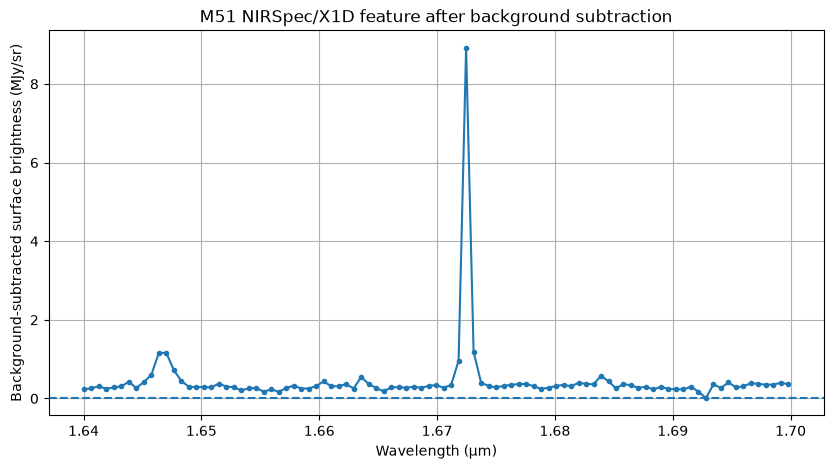

In [36]:
plt.figure(figsize=(10, 5))

plt.plot(
    x1d_wavelength[x1d_window],
    background_subtracted[x1d_window],
    marker="o",
    markersize=3
)

plt.axhline(0, linestyle="--")

plt.xlabel("Wavelength (µm)")
plt.ylabel("Background-subtracted surface brightness (MJy/sr)")
plt.title("M51 NIRSpec/X1D feature after background subtraction")
plt.grid(True)

plt.show()

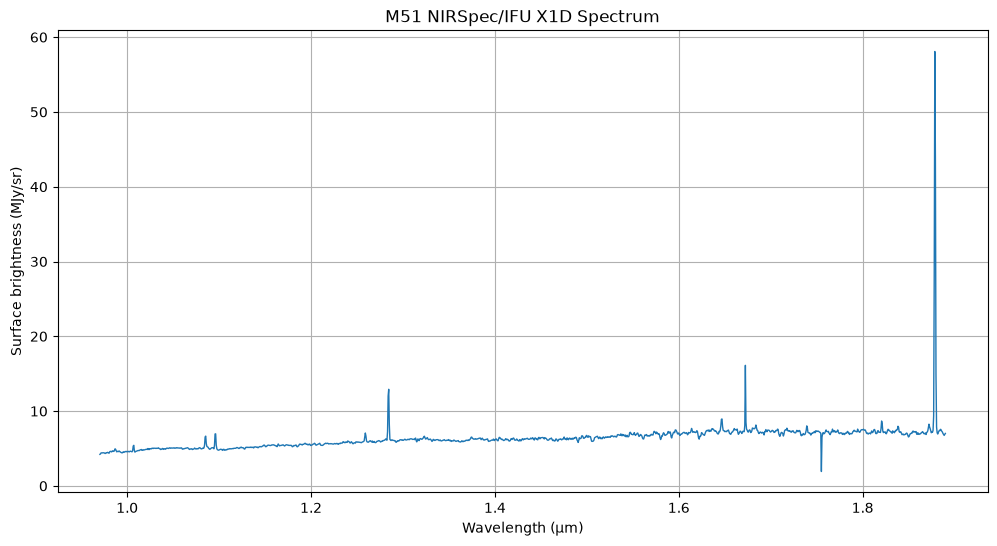

In [37]:
plt.figure(figsize=(12, 6))

plt.plot(
    x1d_wavelength,
    x1d_table["SURF_BRIGHT"],
    linewidth=1
)

plt.xlabel("Wavelength (µm)")
plt.ylabel("Surface brightness (MJy/sr)")
plt.title("M51 NIRSpec/IFU X1D Spectrum")

plt.grid(True)
plt.show()